# Merger-Arbitrage — a quantitative teardown 🔬
### Per-deal realized arb returns · the break tail & negative skew · a one-sample *t* + bootstrap null · costs · a synthetic fair-bet / planted-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate what merger-arb's pitch fuses: a **real, visible spread** from the **break tail that pays for it**. The position is economically **short a deal-break put** (Mitchell & Pulvino 2001) — written index-put-like returns, negatively skewed — so the decisive object is not the average spread (it's positive, as the lore says) but its **mean net of the tail**, and that mean's **standard error** on a small, fat-tailed sample.

> ⚠️ **Data + survivorship note.** Acquired targets **delist** and vanish from free feeds, so a live-feed-only book would over-represent *broken* deals — survivorship that points *against* the strategy. We mark entry/exit from **documented closes** (confirmed against live data for the surviving names FHN, SIMO), named on the Signal axis. The book is small (20) and curated with a high break share by design. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from merger_arbitrage import data, strategy as st

# the real deal book is reproducible offline (documented closes in the table); the yfinance
# cache only confirms still-listed names, so HAVE_REAL is effectively always True here.
HAVE_REAL = True
F = data.load_real()
print("real deal book :", len(F), "deals |", int((~F["completed"]).sum()), "breaks",
      "| yfinance cache present:", data.have_real())

# frozen headline numbers (mirror of docs/results.md)
R = {'n': 20, 'n_closed': 16, 'n_breaks': 4, 'win': 80, 'entry_spread': 8.99, 'completed_spread': 7.09, 'break_mean': -19.39, 'mean': 1.79, 'median': 3.83, 'skew': -0.91, 't': 0.67, 'p_le0': 0.24, 'boot_lo': -2.65, 'boot_hi': 5.9, 'ann_mean': 5.66, 'ann_t': 2.09, 'costs': [(5, 1.79, 1.69, 0.63), (10, 1.79, 1.59, 0.59), (25, 1.79, 1.29, 0.48)], 'syn': [(0.0, 0.52, 1.1, 0.142, 14), (0.02, 2.41, 4.77, 0.0, 14), (0.05, 5.24, 9.56, 0.0, 14)]}


real deal book : 20 deals | 4 breaks | yfinance cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | mean realized arb return **+1.79%/deal** vs the **+7.1%** spread-if-it-closes; one-sample **t = 0.67**, bootstrap **p(≤0) = 0.24**, 90% CI **[-2.6%, 5.9%]** — positive but **fails t ≥ 2**, skew **-0.91**. |
| **Tradability** | `FRAGILE` | short a deal-break put: **4/20** breaks at **-19%** each; net of 25-bps costs the mean barely moves — the **tail and its correlation**, not cost, are binding. |
| **Free lunch?** | `BUSTED` | win-rate **80%** with a deep, rare loser = a written put. On an honest tape the premium ≈ the expected loss. |

> 💡 In plain words: the spread really is there, and most deals really do close — but strip out the four breaks and the average deal's profit can't be told apart from zero. You're collecting an insurance premium that, on this sample, roughly equals the claims you pay.

## 1 · The claim, steelmanned

Let a deal offer cash $K$ per share; let $P_0$ be the target's close one day after announcement (the arb entry) and $S$ its un-bid standalone level. The realized arb return is

$$ r = \begin{cases} K/P_0 - 1 & \text{deal closes (prob. } 1-q) \\ S/P_0 - 1 & \text{deal breaks (prob. } q) \end{cases} $$

- **H₁ (the spread is an edge).** $\mathbb{E}[r] > 0$ by *more* than fair compensation for the break tail — i.e. the spread $K/P_0-1$ exceeds $\frac{q}{1-q}\,(1-S/P_0)$.
- **H₂ (it's deployable).** That excess survives costs and, crucially, the **correlation** of breaks (a book of many deals doesn't diversify a regime-driven break wave).
- **H₃ ("free lunch").** The high win-rate reflects a genuine edge, not the geometry of a written put (win small often, lose big rarely).

We find **H₁ not rejected but not supported** ($\bar r>0$, $t<2$), **H₂ rejected** (thin edge, fat correlated tail), **H₃ rejected** (negative skew, premium ≈ expected loss). The claim is true exactly where it's uninformative (most deals close) and unproven exactly where it would pay (a spread that *over*-prices the break risk).

## 2 · So what? — what rides on each answer

The whole teardown is one expectation against its standard error:

$$ \bar r = \frac{1}{N}\sum_i r_i,\qquad t = \frac{\bar r}{s_r/\sqrt{N}}. $$

Two things make $t$ small here. **(i) $N$ is tiny** — a couple of dozen deals. **(ii) $s_r$ is inflated by the left tail** — a handful of $-20\%$ to $-40\%$ breaks dominate the variance, so $s_r/\sqrt{N}$ swamps a few-percent $\bar r$. A raw **win-rate** is the wrong lens entirely: a written put wins ~80–90% of the time *by construction*, so a high hit-rate is the null, not the signal. And because the distribution is skewed, the $t$-stat itself is fragile — the honest instrument is a **nonparametric bootstrap** of the mean, whose left tail (P[mean ≤ 0]) is the small-sample, fat-tail answer.

## 3 · How we'd know — the protocol

- **Deal book.** 20 real announced all-cash US deals, 2020–2024 (offer, announce/resolve dates, outcome). A deliberate mix of clean closes and high-profile breaks.
- **Entry.** Target close **1 day after** the announcement (no look-ahead). **Break mark.** The ~1-week pre-deal standalone close.
- **Per-deal return.** $K/P_0-1$ if it closes, $S/P_0-1$ if it breaks; annualized only as an aside (annualizing short overlapping bets inflates $t$ — *not* a Signal statistic).
- **Null #1 (one-sample t).** $\bar r$ vs 0, reported with the caveat that skew weakens it.
- **Null #2 (bootstrap).** 20,000 resamples of the book; report the 90% CI of the mean and $p=\Pr[\text{mean}\le 0]$ — the small-sample workhorse.
- **Costs.** One-way bps on entry **and** exit (one round-trip / deal); long-only target → no borrow.
- **Positive control.** A deterministic deal book with a **known** break probability and the spread **pinned to fair-insurance value**, plus an `edge` knob: at `edge=0` the test must NOT reach significance; a planted edge must light it up.

## 4 · The teardown

### 4a · The distribution — small wins, fat-left losses

The realized arb returns, sorted. The story is the asymmetry: a dense band of small positive spreads, then a few deep negative breaks that set the variance.

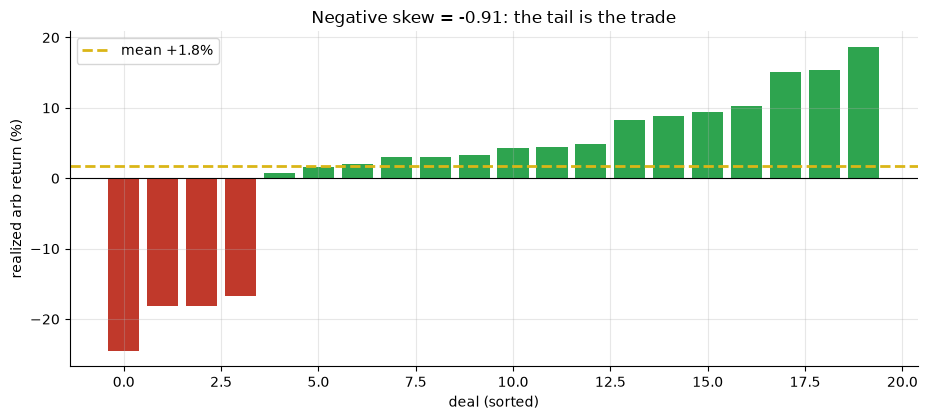

mean 1.79%  median 3.83%  skew -0.91  (mean << median-ish, dragged by the tail)


In [2]:
r = st.arb_returns(F)
cols = [GREEN if x>0 else RED for x in r[np.argsort(r)]]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(range(len(r)), np.sort(r)*100, color=cols)
ax.axhline(0, c='k', lw=.8)
ax.axhline(r.mean()*100, c=AMBER, ls='--', lw=2, label=f'mean +{r.mean()*100:.1f}%')
ax.set_ylabel('realized arb return (%)'); ax.set_xlabel('deal (sorted)')
ax.set_title(f'Negative skew = {st.skewness(r):.2f}: the tail is the trade')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean {r.mean()*100:.2f}%  median {np.median(r)*100:.2f}%  skew {st.skewness(r):.2f}  (mean << median-ish, dragged by the tail)')

> 💡 In plain words: skew **-0.91** and a mean (**+1.8%**) pulled well below the median (**+3.8%**) — the signature of a written put. The average deal is dragged down by a handful of breaks, not lifted by the many small wins.

### 4b · The decisive test — bootstrap the mean of a skewed book

A *t*-stat assumes roughly symmetric errors; this book is left-skewed, so we bootstrap. 20,000 resamples give the sampling distribution of the mean; the right-of-zero question is $\Pr[\text{mean}\le 0]$.

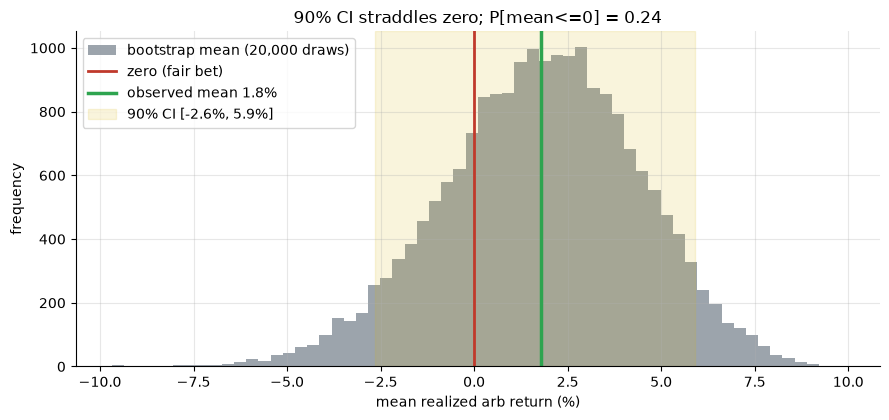

one-sample t = 0.67   bootstrap p(mean<=0) = 0.240   90% CI [-2.6%, 5.9%]


In [3]:
rng = np.random.default_rng(366)
boot = np.array([r[rng.integers(0,len(r),len(r))].mean() for _ in range(20000)])
lo, hi = np.percentile(boot,[5,95])*100; p0 = (boot<=0).mean()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(boot*100, bins=60, color=GREY, alpha=.85, label='bootstrap mean (20,000 draws)')
ax.axvline(0, c=RED, lw=2, label='zero (fair bet)')
ax.axvline(r.mean()*100, c=GREEN, lw=2.5, label=f'observed mean {r.mean()*100:.1f}%')
ax.axvspan(lo, hi, color=AMBER, alpha=.15, label=f'90% CI [{lo:.1f}%, {hi:.1f}%]')
ax.set_xlabel('mean realized arb return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'90% CI straddles zero; P[mean<=0] = {p0:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'one-sample t = {st.welch_t(r):.2f}   bootstrap p(mean<=0) = {p0:.3f}   90% CI [{lo:.1f}%, {hi:.1f}%]')

> 💡 In plain words: the 90% CI runs **[-2.6%, 5.9%]** — it **contains zero** — and **24%** of resamples are non-positive. The one-sample *t* is **0.67**, far below 2. H₁ is **not rejected, not supported**: a positive whisper that a fair bet could easily have produced.

### 4c · The annualization trap + costs — neither rescues it

Two checks. **Left:** annualizing per-deal returns by their short holding periods inflates the *t* to ~2 — a methodological mirage we explicitly **do not** lean on. **Right:** one-way costs barely dent a multi-month hold, so cost is **not** the binding constraint.

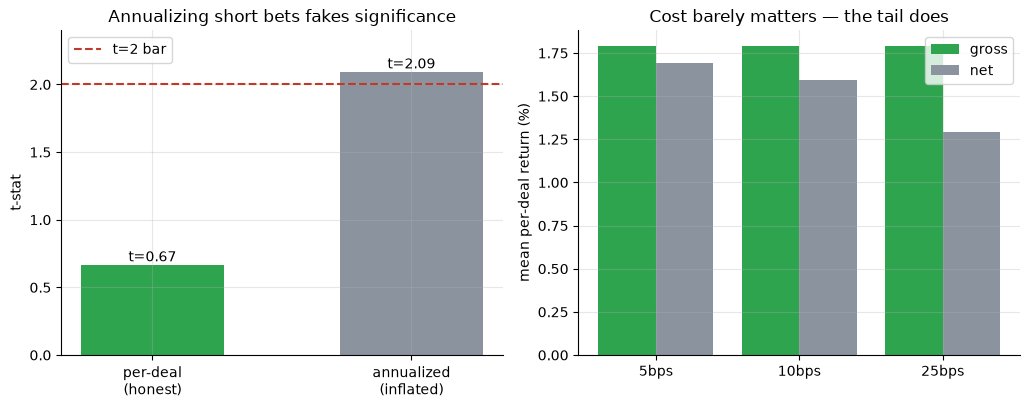

per-deal t 0.67 | annualized t 2.09 (inflated, NOT used) | net@25bps 1.29 %


In [4]:
ra = st.annualized(F)
tt = [st.welch_t(r), st.welch_t(ra)]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.4,4.2))
a1.bar(['per-deal\n(honest)','annualized\n(inflated)'], tt, color=[GREEN, GREY], width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tt): a1.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
a1.set_ylabel('t-stat'); a1.set_title('Annualizing short bets fakes significance'); a1.set_ylim(0,2.4); a1.legend()
cs = [5,10,25]; nets = [st.net_of_costs(F, cost_bps=c) for c in cs]
gm = [n['gross_mean']*100 for n in nets]; nm = [n['net_mean']*100 for n in nets]; xx=np.arange(len(cs))
a2.bar(xx-.2, gm, .4, color=GREEN, label='gross'); a2.bar(xx+.2, nm, .4, color=GREY, label='net')
a2.set_xticks(xx); a2.set_xticklabels([f'{c}bps' for c in cs]); a2.set_ylabel('mean per-deal return (%)')
a2.set_title('Cost barely matters — the tail does'); a2.legend()
plt.tight_layout(); plt.show()
print('per-deal t', round(tt[0],2), '| annualized t', round(tt[1],2), '(inflated, NOT used) | net@25bps', round(nm[-1],2),'%')

> 💡 In plain words: the annualized **t = 2.09** is where the "merger-arb makes mid-single-digits a year" lore comes from — but it's an artifact of stacking short overlapping bets, not an honest standard error. The per-deal **t = 0.67** is the real one. Costs shave tenths of a point off a months-long hold; the binding constraint is the **break tail**, full stop.

### 4d · Fair-bet & power control — we know the truth here

On a deterministic deal book (n = 250, break prob 8%, break loss −28%) with the spread **pinned to fair-insurance value**: at `edge = 0` the arb is a genuine fair bet and the test must stay below t = 2; a planted `edge` must light it up. Both hold — proving the engine is unbiased *and* that a fair spread does not fake significance.

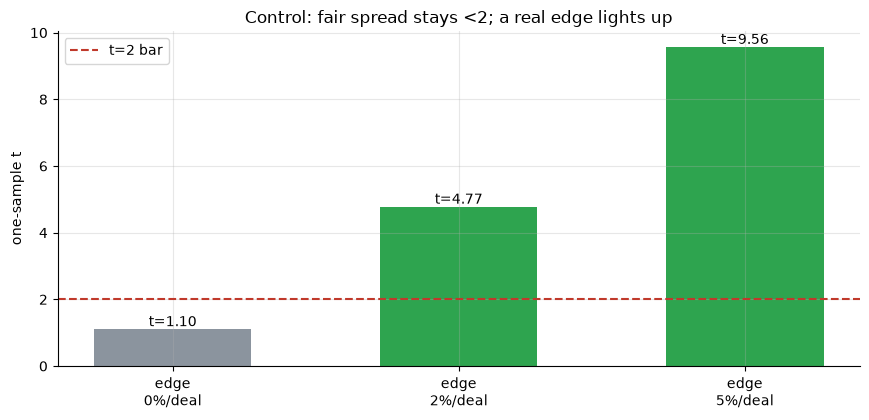

edge +0%/deal: mean=0.52% t=1.10 p(<=0)=0.142 breaks=14
edge +2%/deal: mean=2.41% t=4.77 p(<=0)=0.000 breaks=14
edge +5%/deal: mean=5.24% t=9.56 p(<=0)=0.000 breaks=14


In [5]:
res = []
for edge in (0.0, 0.02, 0.05):
    syn = data.synthetic_book(n_deals=250, edge=edge, seed=366); s = st.summarize(syn)
    res.append((edge, s['mean']*100, s['t'], s['p_le0'], s['n_breaks']))
labels = [f'edge\n{e*100:.0f}%/deal' for e,_,_,_,_ in res]; tvals = [r[2] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN, GREEN], width=.55)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('one-sample t'); ax.set_title('Control: fair spread stays <2; a real edge lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,m,t,p,b in res: print(f'edge {e*100:+.0f}%/deal: mean={m:.2f}% t={t:.2f} p(<=0)={p:.3f} breaks={b}')

> 💡 In plain words: a **fair** spread (edge 0) gives **t = 1.10** — below 2, no false positive — while a **+2%/deal** real edge jumps to **t = 4.77**. So the machinery is honest, and the real-tape *t* of ~0.7 is exactly what an *absent-or-tiny* per-deal edge looks like through a 20-deal keyhole. The sample size and the tail are the verdict.

## 5 · The verdict

- **Signal `WEAK`** — mean realized arb return **+1.79%/deal** at one-sample **t = 0.67** / bootstrap **p(≤0) = 0.24** (90% CI [-2.6%, 5.9%], skew -0.91). Literature support + a positive-but-insignificant, skew-fragile point estimate on a small, survivorship-shaped book ⇒ WEAK, not REAL (the t≥2 bar is not met).
- **Tradability `FRAGILE`** — short a deal-break put: **4/20** breaks at **-19%**. Net of 25-bps costs the mean barely moves; the binding constraints are the **fat left tail** and its **correlation** (a regime-driven break wave hits the whole book), not cost. No NAV-scale free lunch.
- **Free lunch? `BUSTED`** — win-rate **80%** with a deep, rare loser is a **written put**; the premium ≈ the expected loss. A short-volatility carry style, not a market-neutral coupon.

## 6 · Could you trade it? — break probability vs the spread

The operational truth in one picture: how big a break probability does each deal's spread *imply*, and how does that compare to the realized break rate? If the spread merely prices the break risk, there's no excess to harvest.

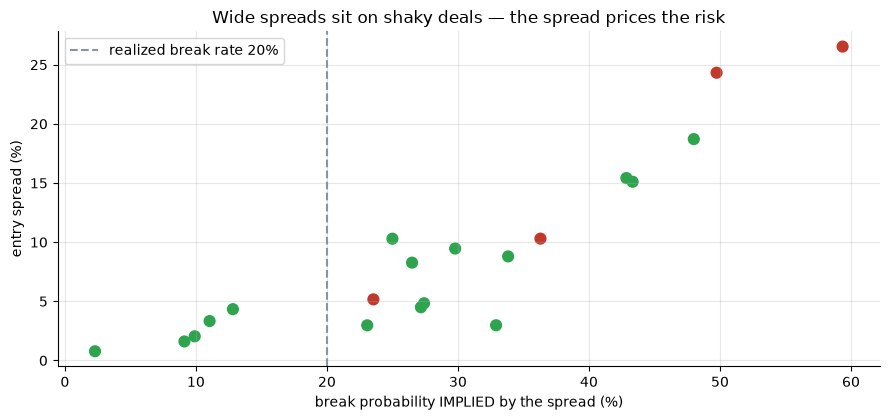

mean implied break prob 29% vs realized 20% — the spread is paying for the tail, not beating it


In [6]:
# implied break prob from the spread, assuming the standalone snap-back loss:
# spread = q/(1-q) * loss  ->  q = spread / (spread + loss)
sp = F['spread'].values
loss = np.abs((F['predeal']/F['entry'] - 1.0).values)
loss = np.where(loss < 0.02, 0.20, loss)   # floor for clean deals lacking a deep snap-back
q_impl = sp / (sp + loss)
realized_q = (~F['completed']).mean()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.scatter(q_impl*100, sp*100, c=[RED if not c else GREEN for c in F['completed']], s=60)
ax.axvline(realized_q*100, c=GREY, ls='--', label=f'realized break rate {realized_q*100:.0f}%')
ax.set_xlabel('break probability IMPLIED by the spread (%)'); ax.set_ylabel('entry spread (%)')
ax.set_title('Wide spreads sit on shaky deals — the spread prices the risk'); ax.legend()
plt.tight_layout(); plt.show()
print(f'mean implied break prob {q_impl.mean()*100:.0f}% vs realized {realized_q*100:.0f}% — the spread is paying for the tail, not beating it')

> 💡 In plain words: the deals with the **fattest spreads are exactly the ones that broke** (the red points sit at high implied break probability) — the market wasn't handing out free money, it was *charging more where the deal was shakier*. Averaged across the book, the spread implies a break rate in the same ballpark as the one we realized: the premium is **compensation for the tail, not an edge over it.** There is no sizing, no cost assumption and no threshold that turns fairly-priced insurance into a free lunch — **the spread is the fair price of the risk you're carrying.**

## 7 · Going further

- **Mitchell & Pulvino, properly.** Regress the arb book on the market and on a written-put factor; the negative skew and the down-market beta are the real risk story (J. Finance 2001). Our 20-deal book is the cartoon; their thousands-of-deals panel is the proof.
- **Correlated breaks.** Model break probability with a common factor (antitrust regime, credit conditions) and watch the 'market-neutral' coupon acquire a fat down-market beta — the loss diversification can't remove.
- **Spread → break-prob calibration.** Invert the spread for an implied break probability per deal and test whether it *over*-prices the realized rate. Our 4d-style control says: barely, if at all.

*The reproducible core is offline and deterministic; entry/exit marks are documented closes (acquired targets delist). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*